In [1]:
# import required packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/home/sakshi/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# prerequisities

import warnings
warnings.filterwarnings(action="ignore")

In [4]:
df=pd.read_csv("Advertising.csv")
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [5]:
# get the statistical informantion about the dataset
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [6]:
#basic info about the dataser
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [7]:
df.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


<Axes: >

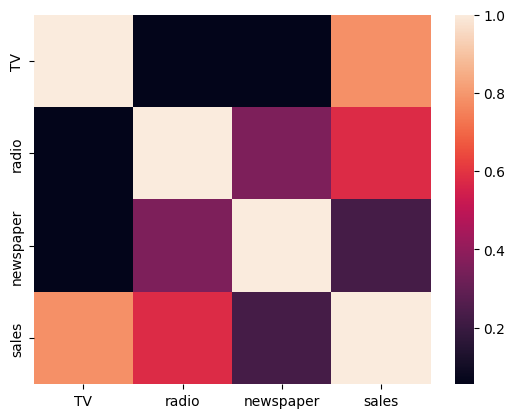

In [10]:
sns.heatmap(df.corr())

In [9]:
#create x

x=df.drop(['newspaper', 'sales'],axis=1)

# create y
y=df['sales']

## Split the data in train and test

In [13]:
from sklearn.model_selection import train_test_split

# split the data
x_train,x_test,y_train,y_test= train_test_split(x,y,train_size=0.8,random_state=123456)

In [14]:
x_train

,TV,radio
100,222.4,4.3
14,204.1,32.9
29,70.6,16.0
21,237.4,5.1
72,26.8,33.0
...,...,...
43,206.9,8.4
171,164.5,20.9
56,7.3,28.1
49,66.9,11.7


## build the model

In [19]:
from sklearn.linear_model import LinearRegression

# create the model
model=LinearRegression()

#fit the train data to generate the model
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
LinearRegression()
In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.

LinearRegression
?Documentation for LinearRegressioniFitted

SyntaxError: invalid syntax (1262825010.py, line 2)

In [22]:
x_train.columns

Index(['TV', 'radio'], dtype='object')

In [23]:
#predict the data
y_pred=model.predict(x_test)

In [24]:
y_test

107     8.7
188    15.9
88     12.9
109    19.8
186    10.3
127     8.8
168    17.1
81     12.3
105    19.2
7      13.2
38     10.1
160    14.4
189     6.7
170     8.4
9      10.6
27     15.9
46     10.6
63     14.0
158     7.3
77     14.2
103    14.7
139    20.7
64     18.0
54     20.2
41     17.1
112    14.1
26     15.0
108     5.3
24      9.7
177    11.7
126     6.6
104    20.7
78      5.3
125    10.6
28     18.9
121     7.0
197    12.8
166     8.0
141    19.2
89     16.7
Name: sales, dtype: float64

In [25]:
y_pred

array([ 7.02356787, 18.57870332, 11.78765376, 19.68845601,  9.6129145 ,
        6.49991683, 17.22538597, 14.57893607, 18.08339323, 12.10654838,
        9.95497448, 14.20559991,  6.02501656,  7.35793681, 12.4630078 ,
       17.02262823,  8.84302434, 13.2359572 , 10.488196  , 13.83667136,
       14.73528677, 19.74755798, 17.07858032, 20.38824586, 17.36180228,
       13.83101875, 15.01387693,  3.51286502,  8.11248621, 12.11414561,
       10.69581134, 20.33013767,  8.85050392,  9.09528654, 19.42563114,
        7.8810059 , 12.7139598 , 10.90632532, 18.510139  , 17.07017534])

### Check the perfromance of the model

In [26]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

MAE = mean_absolute_error(y_test,y_pred)
print(f"MAE ={MAE}")

MAE =1.142650131711361


In [27]:
MSE=mean_squared_error(y_test,y_pred)
print(f"MSE = {MSE}")

MSE = 2.3667572669182957


In [28]:
RMSE=root_mean_squared_error(y_test,y_pred)
print(f"RMSE = {RMSE}")


RMSE = 1.5384268805888357


In [29]:
r2 =r2_score(y_test,y_pred)
print(f"R2 score = {r2 *100 :.2f}%")

R2 score = 88.54%


## Data visualization

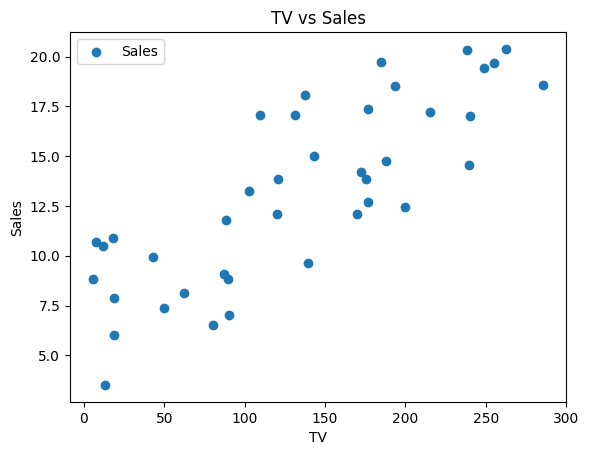

In [30]:
plt.scatter(x_test['TV'],y_pred,label='Sales')

plt.title('TV vs Sales')
plt.xlabel("TV")
plt.ylabel("Sales")
plt.legend()

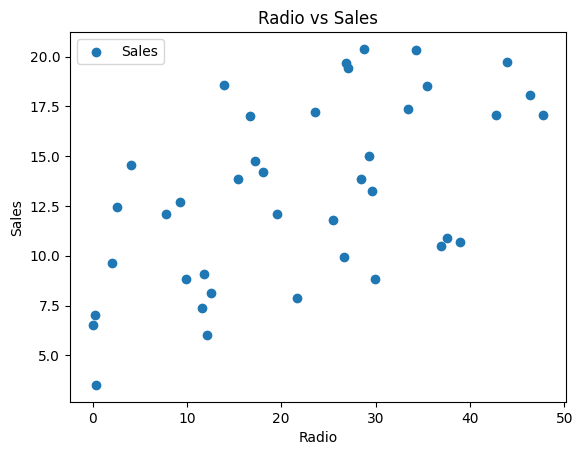

In [31]:
plt.scatter(x_test['radio'],y_pred,label='Sales')

plt.title('Radio vs Sales')
plt.xlabel("Radio")
plt.ylabel("Sales")
plt.legend()